# 02. LIME Explanations

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply LIME for local interpretability
- Generate and interpret local explanations
- Compare LIME with other XAI methods

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME" — that notebook already printed SHAP and LIME side by side; here the audience is the person the decision was made about.

---


# 02. LIME Explanations

## 🚨 THE PROBLEM: We Need Faster, Simpler Explanations

**Remember the limitation from the previous notebook?**

We learned SHAP for explaining model predictions. But we discovered:

**What if we need a simpler, faster explanation method that works with any model?**

**The Problem**: Sometimes we need:
- ❌ **Faster explanations** (SHAP can be slow for large datasets)
- ❌ **Simpler methods** (easier to understand and implement)
- ❌ **Model-agnostic approaches** (work with any black-box model)
- ❌ **Local explanations** (explain individual predictions quickly)

**We've learned:**
- ✅ How to use SHAP for model explanations (Notebook 1)
- ✅ How to generate local and global explanations
- ✅ Feature importance concepts

**What you already learned in Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME":**
- ✅ How to run LIME on a single case and read its local surrogate
- ✅ How LIME's answer compares with SHAP's on that same case

**What you have NOT done yet:**
- ❌ Explain a decision to a **non-technical person who is affected by it**
- ❌ Judge when a local surrogate is **trustworthy enough to act on**
- ❌ Choose between explanation methods for a **specific accountability duty**

**We need LIME (Local Interpretable Model-agnostic Explanations)** to:
1. Provide fast local explanations
2. Work with any black-box model
3. Offer simpler, more intuitive explanations
4. Enable real-time explainability

**This notebook closes that gap.** You have run LIME before (Course 01, Unit 3, lesson 05). Here the question is different: is this local surrogate faithful enough to hand to the person the decision was made about?

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding explainability basics
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Basic ML knowledge**: Model training, predictions

**If you haven't completed these**, you might struggle with:
- Understanding why we need alternative explanation methods
- Knowing how LIME differs from SHAP
- Understanding local interpretability concepts

---

## 🔗 Where This Notebook Fits

**This is the SECOND example in Unit 4** - it teaches you faster, simpler explanations!

**Why this example SECOND?**
- **Before** you can use LIME effectively, you need to understand SHAP (Example 1)
- **Before** you can compare methods, you need multiple approaches
- **Before** you can use counterfactuals, you need local explanations

**Builds on**: 
- 📓 Example 1: SHAP Explanations (we learned SHAP, now we learn LIME!)

**Leads to**: 
- 📓 Example 3: Counterfactual Analysis (what-if explanations)
- 📓 Example 4: Accountability Frameworks (accountability structures)
- 📓 Example 5: Human-in-the-Loop (HITL approaches)
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. LIME provides **alternative approach** (complements SHAP)
2. LIME enables **faster explanations** (critical for real-time systems)
3. LIME shows **model-agnostic** methods (works with any model)

---

## The Story: Fast and Simple Explanations

Imagine you're a loan officer using AI to approve loans. **Before** LIME, you'd use SHAP but it might be too slow for real-time decisions. **After** using LIME, you get fast, simple explanations that show which factors matter most - quick and understandable!

Same with AI: **Before** we have SHAP but it may be slow, now we learn LIME - fast local explanations using simple linear models! **After** LIME, we can explain predictions quickly for any model!

---

## Why LIME Explanations Matter

LIME explanations are essential for ethical AI:
- **Speed**: Fast explanations for real-time systems
- **Simplicity**: Easy to understand for non-technical users
- **Model-Agnostic**: Works with any black-box model
- **Local Focus**: Explains individual predictions clearly
- **Flexibility**: Works with tabular, text, and image data

## Learning Objectives
1. Understand LIME and how it differs from SHAP
2. Learn how to generate LIME explanations
3. Apply LIME to tabular data
4. Understand local interpretability concepts
5. Compare LIME vs SHAP approaches
6. Use LIME for real-time explainability

## 📌 The case: the wolf detector that was a snow detector

The LIME paper itself contains the best argument for LIME (Ribeiro, Singh & Guestrin, KDD
2016). The authors deliberately trained a **bad** image classifier to separate huskies from
wolves — bad in a specific way: on a held-out set of 60 images it predicted "wolf" whenever
there was **snow, or a light background at the bottom** of the photograph, and "husky"
otherwise, regardless of the animal.

Then they ran a human study on **27 graduate students who had each taken at least one
graduate machine-learning course** — precisely the people who should catch this. Each saw ten
predictions, including a husky misclassified as a wolf, and was asked whether they trusted
the algorithm and how they thought it was distinguishing the photos. Then they saw the same
images **with LIME explanations** and were asked again:

| | Before explanations | After explanations |
|---|---|---|
| Trusted the bad model | **10 of 27** | **3 of 27** |
| Named snow/background as a possible feature | **12 of 27** | **25 of 27** |

Ten trained machine-learning students out of 27 trusted a snow detector. The predictions were
mostly correct, so there was nothing in the accuracy to warn them. The explanation is what
moved 22 people to the right answer about what the model was doing.

**The WHY — what goes wrong without local explanation.** Global feature importance (Notebook
01) tells you what the model relies on *on average*. It does not tell the person in front of
you why **their** case came out the way it did, and it will not surface a spurious rule that
fires on a subset. A local explanation is what a caseworker, a clinician or a support agent
can actually use in the ninety seconds they have — and it is fast enough to compute while
they wait.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("titanic")` - 891 real passengers. Six real,
  interpretable features (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `is_female`)
  and the real recorded outcome, `Survived`.
- This is deliberately the same model Unit 2 audited for fairness, so the
  explanations here can be checked against those findings.

**Outputs:** What you'll see when you run the cells

- A LIME explanation for one real passenger, expressed as human-readable rules
- A stability check: the same instance explained twice, to see how much LIME moves
- A direct comparison against the SHAP attribution for the same passenger

---

## Part 1: Same Model, Different Explainer

LIME explains one prediction by fitting a *simple local surrogate model* around the
instance: it perturbs the input, watches the black-box's answers, and fits a small linear
model that is faithful *near this instance only*. We reuse the real Titanic survival
setup from Notebook 01, so the two explainers can be compared on the same model and
the same real person.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Why start here: explanation tools need a real trained model to interrogate.
# We train on the REAL Titanic manifest - real people, a real recorded outcome -
# so the explanations we produce are statements about the world, not about a
# formula we wrote ourselves.

# Build the real dataset and train the model we will explain
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = load("titanic")
# Real missing values, handled openly: 177 ages and 2 ports are genuinely absent.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Six interpretable features. Every one is a real recorded attribute of a real
# passenger - which is what makes an explanation of this model meaningful.
X = pd.DataFrame({
    'Pclass':    df['Pclass'].astype(float),      # ticket class: 1 = first, 3 = third
    'Age':       df['Age'].astype(float),         # years (median-imputed where missing)
    'SibSp':     df['SibSp'].astype(float),       # siblings/spouse aboard
    'Parch':     df['Parch'].astype(float),       # parents/children aboard
    'Fare':      df['Fare'].astype(float),        # ticket price paid
    'is_female': (df['Sex'] == 'female').astype(float),   # 1 = female, 0 = male
})
y = df['Survived'].values                          # 1 = survived, 0 = died

# Hold out a test set, then fit the classifier we will explain.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Real passengers: {len(df)}   (train {len(X_train)} / test {len(X_test)})")
print(f"Survival-prediction model trained. Test accuracy: "
      f"{accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"Real survival rate in the data: {y.mean():.1%}")
print(f"Real survival rate by sex: female {df[df.Sex=='female'].Survived.mean():.1%}, "
      f"male {df[df.Sex=='male'].Survived.mean():.1%}")
print("\nThis is the model Unit 2 audited. Now we ask it to explain itself -")
print("and we will see whether its explanation matches what the audit found.")

titanic: full file, 891 rows.
Real passengers: 891   (train 668 / test 223)
Survival-prediction model trained. Test accuracy: 0.789
Real survival rate in the data: 38.4%
Real survival rate by sex: female 74.2%, male 18.9%

This is the model Unit 2 audited. Now we ask it to explain itself -
and we will see whether its explanation matches what the audit found.


Passenger #0: predicted survival probability 0.08 (actually died)
Pclass        3.00
Age          30.00
SibSp         0.00
Parch         0.00
Fare          8.05
is_female     0.00

LIME explanation (rule -> weight toward 'survived'):
  is_female <= 0.00                   -0.3775
  2.00 < Pclass <= 3.00               -0.0637
  7.90 < Fare <= 13.86                -0.0499
  SibSp <= 0.00                       +0.0474
  Parch <= 0.00                       -0.0252
  28.00 < Age <= 36.00                -0.0176


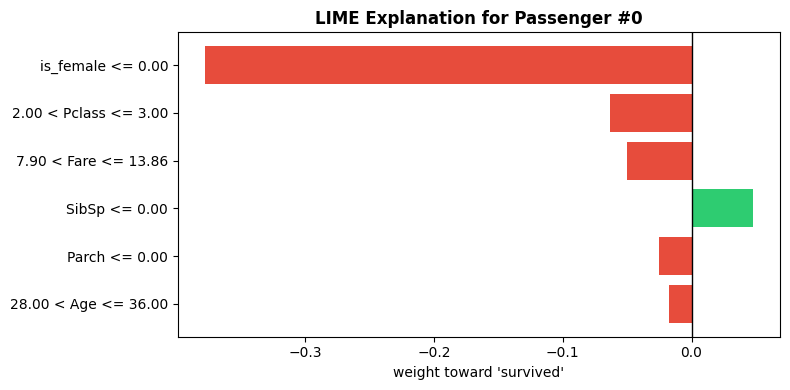


The dominant rule for this passenger: 'is_female <= 0.00' (-0.3775).

STABILITY CHECK - one passenger, one model, four different random seeds
  seed 42: top rule 'is_female <= 0.00'  weight -0.3775
  seed  1: top rule 'is_female <= 0.00'  weight -0.3781
  seed  2: top rule 'is_female <= 0.00'  weight -0.3741


  seed  3: top rule 'is_female <= 0.00'  weight -0.3815

  All four runs produced the same 6 rules.


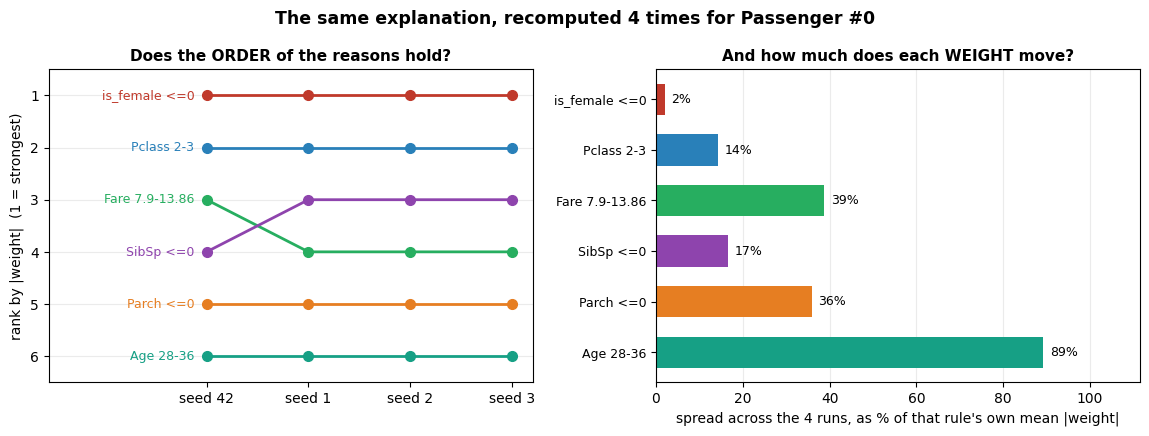

  is_female <=0      -0.3775, -0.3781, -0.3741, -0.3815   spread 0.0074 (2% of its own size)
  Pclass 2-3         -0.0637, -0.0675, -0.0651, -0.0584   spread 0.0091 (14% of its own size)
  Fare 7.9-13.86     -0.0499, -0.0377, -0.0341, -0.0410   spread 0.0158 (39% of its own size)
  SibSp <=0          +0.0474, +0.0511, +0.0433, +0.0465   spread 0.0078 (17% of its own size)
  Parch <=0          -0.0252, -0.0329, -0.0233, -0.0255   spread 0.0096 (36% of its own size)
  Age 28-36          -0.0176, -0.0126, -0.0092, -0.0072   spread 0.0104 (89% of its own size)

  2 of the 6 rules changed rank between runs.
  LIME's answer is not a fixed property of the model - it depends on the
  random perturbations drawn. Fix `random_state` for anything you publish,
  and report that you did.

SHAP vs LIME on the same passenger:
  - SHAP: additive attributions with game-theoretic guarantees; slower;
    deterministic for tree models (TreeExplainer computes exact values)
  - LIME: interpretable RULES from

In [3]:
# Why LIME: it explains ONE prediction by fitting a simple surrogate model
# to the black box's behavior in the neighborhood of that instance.

# Step 2: LIME local explanation for one real passenger
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # silence sklearn feature-name warning from LIME's numpy inputs

# The explainer perturbs feature values around an instance and watches how
# the model's output changes - the surrogate is trained on those perturbations.
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['died', 'survived'],
    mode='classification',
    random_state=42,
)

i = 0
exp = explainer.explain_instance(X_test.iloc[i].values,
                                 model.predict_proba, num_features=6)
proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
print(f"Passenger #{i}: predicted survival probability {proba:.2f} "
      f"(actually {'survived' if y_test[i] == 1 else 'died'})")
print(X_test.iloc[i].round(2).to_string())

pairs = exp.as_list()
print("\nLIME explanation (rule -> weight toward 'survived'):")
for rule, weight in pairs:
    print(f"  {rule:<35} {weight:+.4f}")

# Chart the rules: green rules pushed toward survival, red away from it.
fig, ax = plt.subplots(figsize=(8, 4))
rules = [p[0] for p in pairs][::-1]
weights = [p[1] for p in pairs][::-1]
ax.barh(rules, weights,
        color=['#e74c3c' if w < 0 else '#2ecc71' for w in weights])
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("weight toward 'survived'")
ax.set_title(f'LIME Explanation for Passenger #{i}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

top_rule, top_weight = max(pairs, key=lambda p: abs(p[1]))
print(f"\nThe dominant rule for this passenger: '{top_rule}' "
      f"({top_weight:+.4f}).")

# --- Stability check: LIME samples randomly, so explanations can move ---
# WHY this matters: an explanation you show a regulator must be reproducible,
# and it must survive being recomputed. We explain the SAME passenger with the
# SAME model four times, changing only LIME's random seed. Fixed seeds (not an
# unseeded explainer) so this notebook prints the same numbers for every student.
print("\n" + "=" * 70)
print("STABILITY CHECK - one passenger, one model, four different random seeds")
print("=" * 70)
seeds = [42, 1, 2, 3]
runs = []
for s in seeds:
    e = LimeTabularExplainer(
        training_data=X_train.values, feature_names=list(X_train.columns),
        class_names=['died', 'survived'], mode='classification',
        random_state=s).explain_instance(X_test.iloc[i].values,
                                         model.predict_proba, num_features=6)
    runs.append(dict(e.as_list()))
    top = max(runs[-1].items(), key=lambda kv: abs(kv[1]))
    print(f"  seed {s:>2}: top rule '{top[0]}'  weight {top[1]:+.4f}")

# Only compare rules that every run actually produced.
common = sorted(set.intersection(*[set(r) for r in runs]),
                key=lambda r: -abs(runs[0][r]))
print(f"\n  All four runs produced the same {len(common)} rules.")


def short(rule):
    """Turn LIME's rule text into a compact axis label, e.g. 'Pclass 2-3'."""
    q = rule.split()
    if len(q) == 3:                                   # 'is_female <= 0.00'
        return f"{q[0]} {q[1]}{float(q[2]):g}"
    return f"{q[2]} {float(q[0]):g}-{float(q[4]):g}"  # '2.00 < Pclass <= 3.00'


# Rank each rule by |weight| within each run: rank 1 = the rule LIME would put
# at the top of the letter you send the customer.
ranks = []
for r in runs:
    order = sorted(common, key=lambda k: -abs(r[k]))
    ranks.append({rule: order.index(rule) + 1 for rule in common})

# Relative wobble: how far a weight travelled across the four runs, measured
# against its own average size. 5% is noise; 90% means the number is not a number.
spread = {r: max(d[r] for d in runs) - min(d[r] for d in runs) for r in common}
mean_abs = {r: np.mean([abs(d[r]) for d in runs]) for r in common}
relative = {r: 100 * spread[r] / mean_abs[r] for r in common}

palette = ['#c0392b', '#2980b9', '#27ae60', '#8e44ad', '#e67e22', '#16a085']
colour = {rule: palette[k % len(palette)] for k, rule in enumerate(common)}

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))

ax = axes[0]
for rule in common:
    ys = [ranks[k][rule] for k in range(len(seeds))]
    ax.plot(range(len(seeds)), ys, '-o', color=colour[rule], lw=2, ms=7)
    ax.text(-0.12, ys[0], short(rule), ha='right', va='center',
            fontsize=9, color=colour[rule])
ax.set_xticks(range(len(seeds)))
ax.set_xticklabels([f"seed {s}" for s in seeds])
ax.set_yticks(range(1, len(common) + 1))
ax.set_ylim(len(common) + 0.5, 0.5)                 # rank 1 at the top
ax.set_xlim(-1.55, len(seeds) - 0.8)
ax.set_ylabel('rank by |weight|  (1 = strongest)')
ax.set_title('Does the ORDER of the reasons hold?', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

ax = axes[1]
ys = range(len(common))
ax.barh(list(ys), [relative[r] for r in common],
        color=[colour[r] for r in common], height=0.62)
for k, rule in enumerate(common):
    ax.text(relative[rule] + 1.5, k, f"{relative[rule]:.0f}%",
            va='center', fontsize=9)
ax.set_yticks(list(ys))
ax.set_yticklabels([short(r) for r in common], fontsize=9)
ax.invert_yaxis()                                    # same top-to-bottom order
ax.set_xlim(0, max(relative.values()) * 1.25)
ax.set_xlabel("spread across the 4 runs, as % of that rule's own mean |weight|")
ax.set_title('And how much does each WEIGHT move?', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)

fig.suptitle(f'The same explanation, recomputed 4 times for Passenger #{i}',
             fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

for rule in common:
    vals = ', '.join(f"{d[rule]:+.4f}" for d in runs)
    print(f"  {short(rule):<18} {vals}   spread {spread[rule]:.4f} "
          f"({relative[rule]:.0f}% of its own size)")
swaps = sum(1 for rule in common
            if len({ranks[k][rule] for k in range(len(seeds))}) > 1)
print(f"\n  {swaps} of the {len(common)} rules changed rank between runs.")
print("  LIME's answer is not a fixed property of the model - it depends on the")
print("  random perturbations drawn. Fix `random_state` for anything you publish,")
print("  and report that you did.")

print("\nSHAP vs LIME on the same passenger:")
print("  - SHAP: additive attributions with game-theoretic guarantees; slower;")
print("    deterministic for tree models (TreeExplainer computes exact values)")
print("  - LIME: interpretable RULES from a local surrogate; fast; varies with")
print("    the random perturbations, as the stability check above shows")
print("  - Both explain ONE prediction here, and both are post-hoc: they")
print("    approximate the model rather than reveal its internals.")

**Read the figure.** Both panels describe the *same* passenger explained four times by the
*same* model — only LIME's random seed changed.

*Left — does the order hold?* Six coloured lines, one per rule, tracking the rank each rule was
given. Four of the six lines are flat: `is_female` is rank 1 in every run, `Pclass` rank 2,
`Parch` rank 5, `Age` rank 6. But the green line (`Fare 7.9–13.86`) and the purple line
(`SibSp ≤ 0`) **cross** between seed 42 and seed 1 and stay swapped. Read that as a caseworker
would: the third reason you would have written in the letter depends on a random number.

*Right — how much does each weight move?* Bars are the spread across the four runs measured
against each rule's own average size, so a 2% bar and an 89% bar are directly comparable. The
headline is solid — `is_female` moves by **2%** — and the detail is not: `Fare` moves **39%**,
`Parch` **36%**, and `Age` **89%** of its own magnitude. The number is nearly as large as the
effect it claims to measure.

**What this proves.** LIME's *conclusion* here is stable; LIME's *reasons past the first one*
are not. That distinction matters when the explanation is the deliverable. Reporting "sex was
decisive" is defensible from this run. Reporting "and fare mattered more than travelling
alone" is not — a different seed reverses it. Fix `random_state`, and say in writing that you
did, because a reproducible explanation and a *stable* one are not the same claim.

## 💬 Discuss

Your own run explained one real passenger four times, changing only LIME's random seed. The
top rule was `is_female <= 0.00` every time, with weights **−0.3775, −0.3781, −0.3741,
−0.3815** — a spread of **0.0074**, about **2%** of its own size. The smaller rules held up far
worse: `Age 28–36` moved by **89%** of its own weight, and **2 of the 6 rules changed rank**
between runs. SHAP, on the same model and the same passenger, attributed **−0.1193** to
`is_female`.

1. **Two methods, two numbers, one passenger.** LIME says −0.38, SHAP says −0.12, for the
   same feature and the same prediction. They are not measuring the same quantity — LIME
   fits a local surrogate, SHAP allocates the prediction additively — but the person you are
   explaining to does not know that and will ask which is right. What do you tell them? And
   what would you do if the two methods disagreed about the **ranking** rather than the
   magnitude?
2. **Is a randomised explanation admissible?** Rerun the cell and the number moves. Fixing
   `random_state` makes it reproducible, but that is reproducing *one draw*, not converging on
   a truth. If a bank must give a legally required statement of reasons (Notebook 03), is an
   explanation that depends on a seed good enough? Would you accept it from a supplier?
   Would a court?
3. **What would LIME have caught here?** In the husky/wolf study the explanation revealed a
   feature nobody had intended the model to use. On the Titanic model, the top rule is sex —
   which everybody already expected. So did LIME earn its place in this notebook, or did it
   just confirm a prior? Say what result *would* have made it earn its place, and design the
   check you would run to find that result if it existed.


---

## 🚫 When LIME Explanations Hit a Limitation

### The Limitation We Discovered

We've learned LIME for fast, local explanations. **But there's still a challenge:**

**What if we need to understand "what if" scenarios - how would predictions change if features were different?**

LIME works well when:
- ✅ We need fast local explanations
- ✅ We want to understand current predictions
- ✅ We can use model-agnostic methods

**But we also need:**
- ❌ **Counterfactual explanations** (what-if scenarios)
- ❌ **Actionable insights** (what to change to get different outcomes)
- ❌ **Alternative scenarios** (how predictions would change)
- ❌ **Causal reasoning** (understanding cause-effect relationships)

### Why This Is a Problem

When we only have feature importance:
- We know what features matter, but not what to change
- We can't explore alternative scenarios
- We can't understand "what if" questions
- We can't provide actionable recommendations

### The Solution: Counterfactual Analysis

We need **counterfactual analysis** to:
1. Understand "what if" scenarios
2. Provide actionable insights
3. Explore alternative outcomes
4. Enable causal reasoning

**This is exactly what we'll learn in the next notebook: Counterfactual Analysis!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP for explanations (Notebook 1)
- ✅ How to use LIME for fast explanations (This notebook!)
- ✅ **The limitation**: We need "what if" scenarios!

**Next notebook**: `03_counterfactual_analysis.ipynb`
- Learn about counterfactual explanations
- Understand "what if" scenarios
- Explore alternative outcomes
- Provide actionable insights

## ⚠️ Where this breaks

- **LIME is stochastic, and you measured it.** The same passenger explained four times gave
  four different weights (spread 0.0141 here — small, because this model is smooth and this
  feature dominant). On a rugged decision surface the spread can be large enough to reorder
  the features. Fix the seed for anything you publish, report that you fixed it, and report
  the spread across seeds when it matters.
- **"Local" has no agreed definition.** LIME perturbs around the instance using a kernel with
  a **width you choose**. Change the width and you change the explanation, because you have
  changed what "nearby" means. There is no principled default, and almost nobody reports the
  value they used.
- **The surrogate is linear; the model is not.** LIME's answer is faithful only in a
  neighbourhood, and it cannot tell you how big that neighbourhood is. A rule like
  `7.90 < Fare <= 13.86` reads like a fact about the model and is a fact about one linear fit
  near one point — Notebook 03 traces the model across the whole range of `Fare` and finds
  **six** decision-boundary crossings.
- **Both LIME and SHAP can be fooled deliberately.** Slack et al. (2020) built classifiers
  that are extremely biased on COMPAS data while returning innocuous explanations from both
  methods. Post-hoc explanation is not an audit, and an explanation the vendor generated is
  not evidence.
- **Speed was the reason to reach for LIME, and it is not always true.** LIME's cost scales
  with the number of perturbations; `TreeExplainer` computes exact SHAP values for tree
  ensembles very fast. For the model in this notebook, SHAP is both exact *and* competitive —
  so "use LIME because it is faster" is a claim to test on your own model, not to assume.

**The cheaper alternative:** where the decision is high-stakes and the surface is rugged,
skip post-hoc explanation and ship an **inherently interpretable model**. Where you need one
number for a caseworker, a **counterfactual** (Notebook 03) is usually more useful than an
attribution, because it tells the person what to change rather than what went wrong.


## 🔭 State of the field (2026)

LIME's core idea - perturb the input, watch the output move, fit something simple to the neighbourhood
- survived the move to language models; its 2016 packaging did not. For generative text, practitioners
now perturb the *context* at several granularities at once (sentences, phrases, tokens) and score how
much each part moved the generated output, which is exactly the generalisation of perturbation-based
attribution that MExGen works out for LLMs (Paes et al., 2024, arXiv:2403.14459). The tempting shortcut
is to skip all of that and just ask the model to explain itself; 2024-2026 work is blunt that a fluent,
plausible self-explanation is not evidence about the computation that produced the answer, and that
optimising explanations for human approval trades faithfulness away (Agarwal, Tanneru & Lakkaraju,
2024, arXiv:2402.04614).

Learn LIME first, because it makes the loop visible. The instability you measured here - four runs on
one passenger, the same verdict but different reasons past the first feature - is the same instability
the newer methods have to manage, and you can only recognise it in an LLM explanation because you
watched it happen in a model small enough to check. LIME is also what the official plan names.

## 📚 References

1. Ribeiro, M. T., Singh, S. & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD 2016. <https://arxiv.org/abs/1602.04938>
2. Slack, D., Hilgard, S., Jia, E., Singh, S. & Lakkaraju, H. (2020). *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods*. AIES 2020. <https://arxiv.org/abs/1911.02508>
3. Molnar, C. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (online book). <https://christophm.github.io/interpretable-ml-book/>
4. Paes, L. M., Wei, D., Do, H. J., Strobelt, H., Luss, R., Dhurandhar, A., et al. (2024). *Multi-Level Explanations for Generative Language Models* (MExGen). <https://arxiv.org/abs/2403.14459>
5. Agarwal, C., Tanneru, S. H. & Lakkaraju, H. (2024). *Faithfulness vs. Plausibility: On the (Un)Reliability of Explanations from Large Language Models*. <https://arxiv.org/abs/2402.04614>
